# 実験結果の可視化

`outputs/` ディレクトリ内に保存された実験結果（`log.json`）を再帰的に走査し，同一条件（実験・手法・
ハイパーパラメータ）における全Seedの結果から平均と標準偏差を計算してプロットする．

比較対象とする実験・手法・ハイパーパラメータは，下のセルの変数で指定する．

In [1]:
import json
import os
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# 日本語ラベルを正しく描画するため，IPAexゴシックフォントを明示的に登録する
_JP_FONT_PATH = "/usr/share/fonts/opentype/ipaexfont-gothic/ipaexg.ttf"
if os.path.exists(_JP_FONT_PATH):
    fm.fontManager.addfont(_JP_FONT_PATH)
    plt.rcParams["font.family"] = fm.FontProperties(fname=_JP_FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

OUTPUTS_ROOT = Path("outputs")


## 結果の読み込み

`outputs/{experiment}/{method}/{hyperparams}/{seed}/log.json` を再帰的に走査し，
`(experiment, method, hyperparams)` ごとに全Seedのログを集約する．

In [2]:
def load_all_results(outputs_root: Path) -> dict:
    """
    概要: outputs/ 以下の全 log.json を再帰的に読み込み，(experiment, method, hyperparams) を
        キーとして，Seedごとのログのリストにまとめる．
    引数: outputs_root (Path)．走査対象のルートディレクトリ．
    戻り値: results (dict)．
        key: (experiment, method, hyperparams) のタプル．
        value: {"seed_logs": [log_dict, ...], "configs": [config_dict, ...]}
    """
    results = {}
    for log_path in sorted(outputs_root.glob("*/*/*/*/log.json")):
        seed_dir = log_path.parent
        hp_dir = seed_dir.parent
        method_dir = hp_dir.parent
        experiment_dir = method_dir.parent

        key = (experiment_dir.name, method_dir.name, hp_dir.name)
        with open(log_path) as f:
            log = json.load(f)

        config_path = seed_dir / "config.json"
        config = {}
        if config_path.exists():
            with open(config_path) as f:
                config = json.load(f)

        results.setdefault(key, {"seed_logs": [], "configs": []})
        results[key]["seed_logs"].append(log)
        results[key]["configs"].append(config)

    return results


all_results = load_all_results(OUTPUTS_ROOT)
for key, value in all_results.items():
    print(key, "-> Seed数:", len(value["seed_logs"]))


('ex001_mushroom_svrg', 'ASAI_SVRG', 'eta0.169770_lambda0.01_K7311_epochs60') -> Seed数: 5
('ex001_mushroom_svrg', 'NFG_SVRG', 'eta0.169770_lambda0.01_K7311_epochs60') -> Seed数: 5
('ex001_mushroom_svrg', 'SGD', 'eta0.169770_lambda0.01_K7311_epochs60') -> Seed数: 5
('ex001_mushroom_svrg', 'SVRG', 'eta0.169770_lambda0.01_K7311_epochs60') -> Seed数: 5
('ex002_cifar10_cnn', 'ASAI_SVRG', 'lr0.001_bs128_epochs120') -> Seed数: 5
('ex002_cifar10_cnn', 'ASAI_SVRG', 'lr0.001_bs128_epochs15') -> Seed数: 5
('ex002_cifar10_cnn', 'NFG_SVRG', 'lr0.001_bs128_epochs120') -> Seed数: 5
('ex002_cifar10_cnn', 'NFG_SVRG', 'lr0.001_bs128_epochs15') -> Seed数: 5
('ex002_cifar10_cnn', 'SGD', 'lr0.001_bs128_epochs120') -> Seed数: 5
('ex002_cifar10_cnn', 'SGD', 'lr0.001_bs128_epochs15') -> Seed数: 5
('ex002_cifar10_cnn', 'SVRG', 'lr0.001_bs128_epochs120') -> Seed数: 5
('ex002_cifar10_cnn', 'SVRG', 'lr0.001_bs128_epochs15') -> Seed数: 5
('ex003_cifar10_resnet_minmax', 'ASAI_SVRG', 'lr0.01_bs128_lambda0.0005_epochs30') -> Se

## 平均・標準偏差の計算

同一条件の全Seedのログについて，指定した横軸・縦軸それぞれの平均値と標準偏差を計算する．
横軸（`oracle_calls`，`epoch`，`elapsed_time`）はSeedによらず共通の値であるため，1本目のログの値を
そのまま用いる．

In [3]:
def aggregate_seeds(seed_logs: list, x_key: str, y_key: str, x_scale: float = 1.0):
    """
    概要: 複数Seedのログから，指定した横軸・縦軸について平均値と標準偏差を計算する．
    引数:
        seed_logs (list of dict)．各Seedの `ResultLogger.history` に対応する辞書のリスト．
        x_key (str)．横軸として用いる指標名（"oracle_calls", "epoch", "elapsed_time" のいずれか）．
        y_key (str)．縦軸として用いる指標名（例: "objective_gap", "accuracy", "approx_error"）．
        x_scale (float) = 1.0．横軸の値を割るスケール．例えば x_key="oracle_calls" のとき
            N_train を渡すと，勾配計算回数をデータ数で割った #grad/N（SGDにおける1エポック
            相当の計算量）に変換できる．
    戻り値:
        x (numpy.ndarray)．横軸の値（x_scaleで除算済み）．
        mean (numpy.ndarray)．縦軸の平均値．
        std (numpy.ndarray)．縦軸の標準偏差．
    """
    x = np.array(seed_logs[0][x_key], dtype=np.float64) / x_scale
    y_values = np.array([log[y_key] for log in seed_logs], dtype=np.float64)

    mean = np.nanmean(y_values, axis=0)
    std = np.nanstd(y_values, axis=0)
    return x, mean, std


def get_n_train(all_results: dict, experiment: str):
    """
    概要: 指定した実験のいずれかの条件のconfig.jsonから，学習用データ数 N_train を取得する．
        #grad/N（勾配計算回数をデータ数で割った値）を計算するために用いる．
    引数:
        all_results (dict)．load_all_results の戻り値．
        experiment (str)．実験名．
    戻り値: N_train (int or None)．該当するconfigが見つからない場合はNone．
    """
    for (exp, _method, _hp), value in all_results.items():
        if exp != experiment:
            continue
        for config in value["configs"]:
            if "N_train" in config:
                return config["N_train"]
    return None


## 可視化する条件の指定

人間が比較したい実験・手法・ハイパーパラメータを，下記の変数で指定する．
`EXPERIMENT` は対象実験名，`HYPERPARAMS` は比較する各実験のハイパーパラメータ条件
（複数のハイパーパラメータ条件をまたいで比較する場合はキーを増やす），`METHODS` は比較する手法，
`METHOD_COLORS` は手法ごとの色を指定する．

In [4]:
EXPERIMENT = "ex004_cifar10_resnet_minmax"

# 対象実験のハイパーパラメータ条件名（outputs/{EXPERIMENT}/{method}/ 以下のディレクトリ名）
# None の場合は各手法で最初に見つかった条件を自動選択する
HYPERPARAMS = None

METHODS_BY_EXPERIMENT = {
    "ex001_mushroom_svrg": ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"],
    "ex002_cifar10_cnn": ["SGD", "SVRG", "NFG_SVRG", "ASAI_SVRG"],
    "ex003_cifar10_resnet_minmax": ["SGD", "SVRG", "NFG", "ASAI_SVRG"],
    "ex004_cifar10_resnet_minmax": ["SGD", "SVRG", "NFG", "ASAI_SVRG"],
}
METHODS = METHODS_BY_EXPERIMENT[EXPERIMENT]
METHOD_COLORS = {
    "SGD": "#7f7f7f",
    "SVRG": "#1f77b4",
    "NFG_SVRG": "#ff7f0e",
    "NFG": "#ff7f0e",
    "ASAI_SVRG": "#d62728",
}

# N_train で正規化した #grad/N（SGDにおける1エポック相当の計算量）を横軸に用いる．
N_TRAIN = get_n_train(all_results, EXPERIMENT)

X_AXES = [
    ("oracle_calls", "勾配計算回数 (#grad/N，SGDの1エポック相当)"),
    ("epoch", "エポック数"),
    ("elapsed_time", "経過時間 [s]"),
]
X_SCALE_BY_KEY = {"oracle_calls": N_TRAIN if N_TRAIN else 1, "epoch": 1, "elapsed_time": 1}

# 実験ごとに記録されている指標名が異なるため，実験名をキーとして縦軸の候補を切り替える．
# ex001（凸設定）は最適値 f(w*) が既知のため目的関数の"誤差"を，ex002・ex003・ex004（非凸設定）は
# f(w*) が定義できないため目的関数の値そのもの（学習損失）を用いる．
Y_AXES_BY_EXPERIMENT = {
    "ex001_mushroom_svrg": [
        ("objective_gap", "目的関数の誤差 $f(z_s) - f(w^*)$"),
        ("accuracy", "分類精度 (Accuracy)"),
        ("approx_error", "フル勾配の近似誤差 $\\|e_s\\|^2$"),
    ],
    "ex002_cifar10_cnn": [
        ("train_loss", "目的関数の値 $f(z_s)$（学習損失）"),
        ("test_accuracy", "分類精度 (Accuracy，検証用データ)"),
        ("approx_error", "フル勾配の近似誤差 $\\|e_s\\|^2$"),
    ],
    "ex003_cifar10_resnet_minmax": [
        ("train_loss", "目的関数の値 $f(z_s)$（学習損失，対数スケール）"),
        ("test_accuracy", "分類精度 (Accuracy，検証用データ)"),
        ("approx_error", "フル勾配の近似誤差 $\\|e_s\\|^2$"),
    ],
    "ex004_cifar10_resnet_minmax": [
        ("train_loss", "目的関数の値 $f(z_s)$（学習損失，対数スケール）"),
        ("test_accuracy", "分類精度 (Accuracy，検証用データ)"),
        ("approx_error", "フル勾配の近似誤差 $\\|e_s\\|^2$"),
    ],
}
Y_AXES = Y_AXES_BY_EXPERIMENT[EXPERIMENT]

# 指定した縦軸を描画しない手法（SGDには近似誤差 ||e_s||^2 が定義されない）
SKIP_METHOD_FOR_YKEY = {"approx_error": {"SGD"}}

# 対数スケールで描画する縦軸（値が広い範囲にわたる指標）
LOG_SCALE_YKEYS = {"objective_gap", "approx_error", "train_loss"}


def resolve_hyperparams(all_results: dict, experiment: str, method: str, hyperparams):
    """
    概要: 指定条件に対応するハイパーパラメータ名を解決する．
    引数:
        all_results (dict)．load_all_results の戻り値．
        experiment (str)．実験名．
        method (str)．手法名．
        hyperparams (str or None)．指定されたハイパーパラメータ名．Noneの場合は自動選択する．
    戻り値: hp_name (str or None)．該当する結果が存在しない場合はNone．
    """
    if hyperparams is not None:
        return hyperparams

    for exp, meth, hp in all_results:
        if exp == experiment and meth == method:
            return hp
    return None


## グラフの描画

3種類の横軸 × 3種類の縦軸の組み合わせで，4手法の平均値（実線）と標準偏差（塗りつぶし）を
プロットする．`approx_error`（フル勾配の近似誤差）はSGDには定義されないため描画対象から除く．
グラフは `outputs/{EXPERIMENT}/` 以下に保存する．

/tmp/ipykernel_1845193/3972500606.py:19: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y_values, axis=0)
/home/user/workspace/ASAI_SVRG_programs/.venv_pytorch/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/user/workspace/ASAI_SVRG_programs/.venv_pytorch/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1899: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


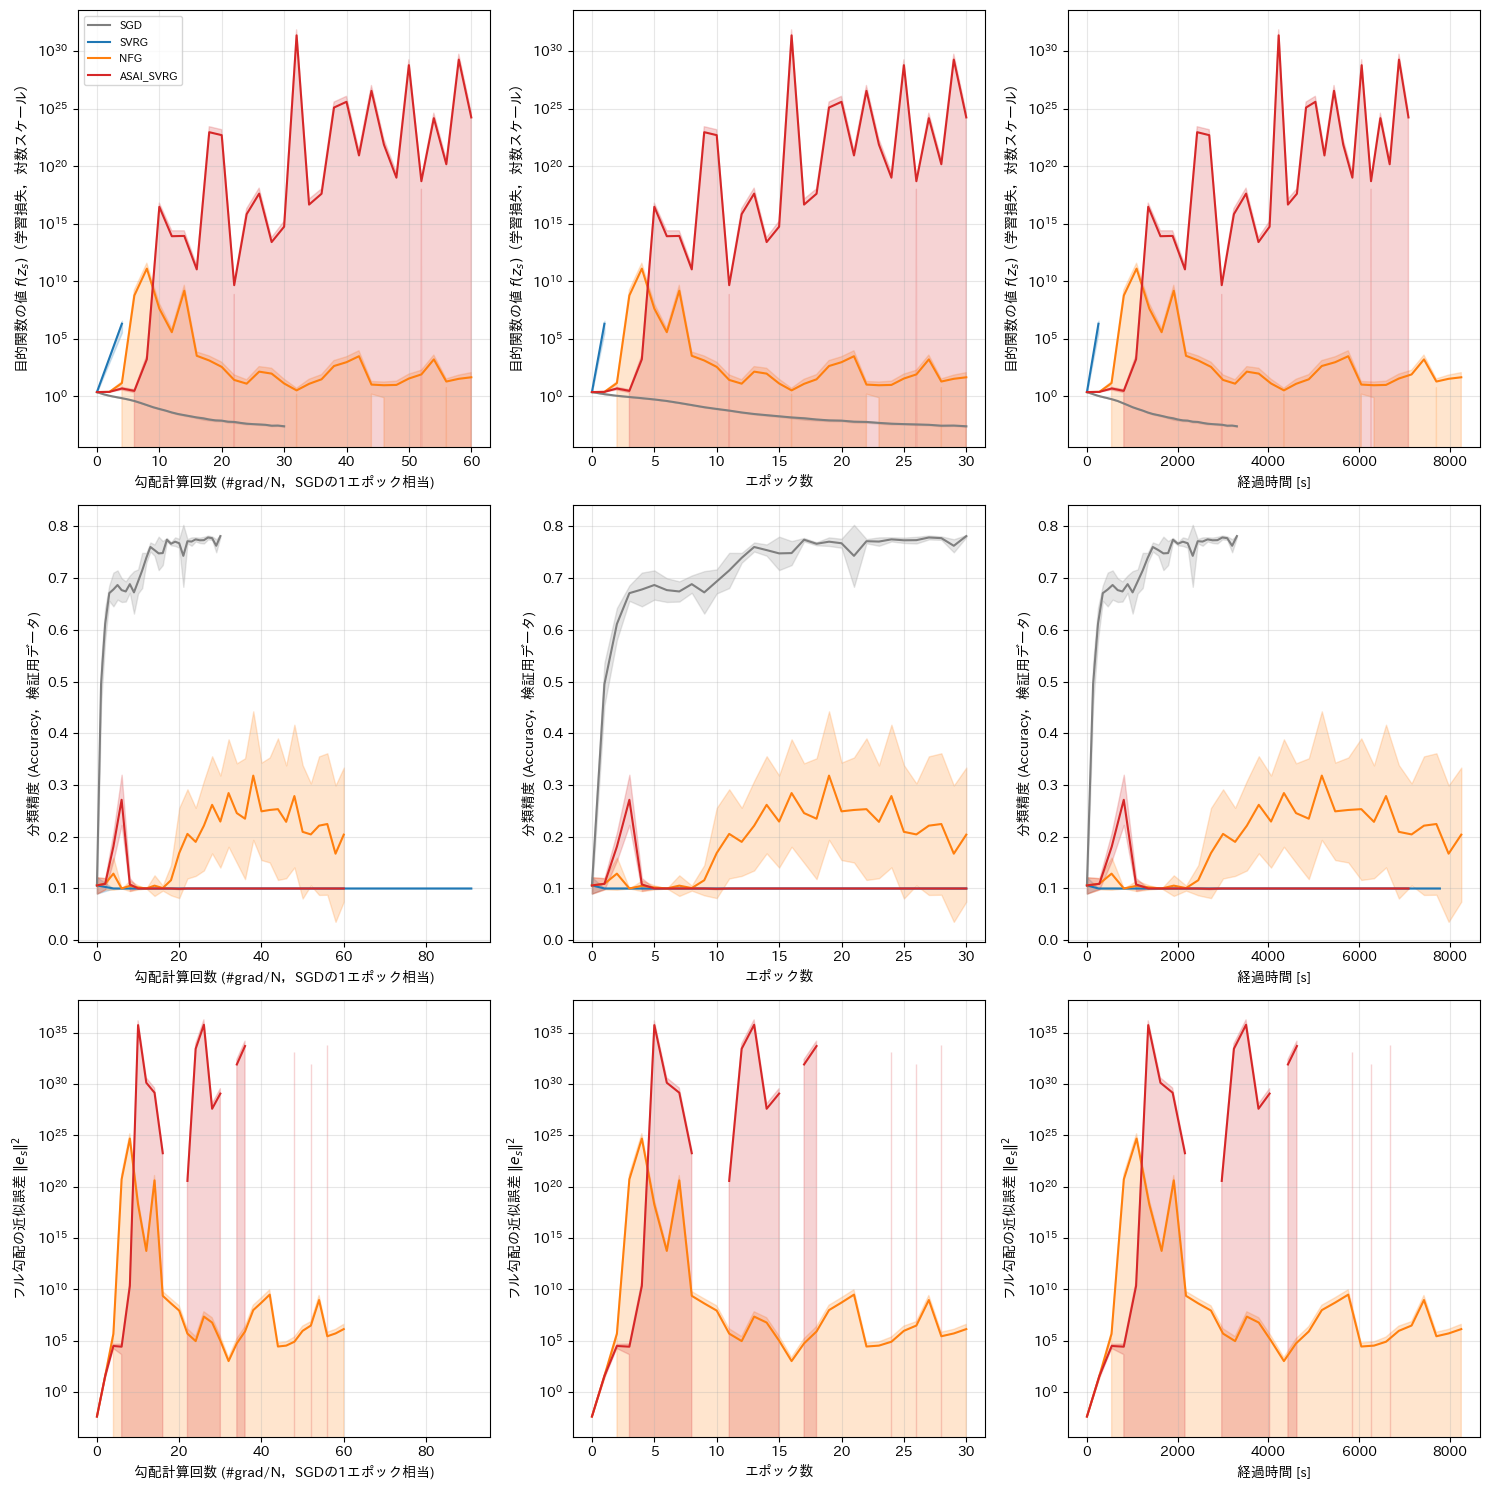

In [5]:
save_dir = OUTPUTS_ROOT / EXPERIMENT
save_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(Y_AXES), len(X_AXES), figsize=(15, 15))

for row, (y_key, y_label) in enumerate(Y_AXES):
    for col, (x_key, x_label) in enumerate(X_AXES):
        ax = axes[row, col]

        for method in METHODS:
            if method in SKIP_METHOD_FOR_YKEY.get(y_key, set()):
                continue

            hp_name = resolve_hyperparams(all_results, EXPERIMENT, method, HYPERPARAMS)
            key = (EXPERIMENT, method, hp_name)
            if key not in all_results:
                continue

            seed_logs = all_results[key]["seed_logs"]
            x, mean, std = aggregate_seeds(seed_logs, x_key, y_key, x_scale=X_SCALE_BY_KEY[x_key])

            color = METHOD_COLORS.get(method)
            ax.plot(x, mean, label=method, color=color, linewidth=1.5)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

        if y_key in LOG_SCALE_YKEYS:
            ax.set_yscale("log")
        if x_key == "oracle_calls":
            ax.set_xscale("linear")

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(save_dir / "comparison_all_axes.png", dpi=150)
plt.show()


## 個別グラフの保存

論文へ掲載する図として，横軸=エポック数，縦軸=目的関数の誤差／分類精度／フル勾配の近似誤差の
3枚を個別に，正方形（`figsize=(5, 5)`）で保存する．

/tmp/ipykernel_1845193/3972500606.py:19: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(y_values, axis=0)


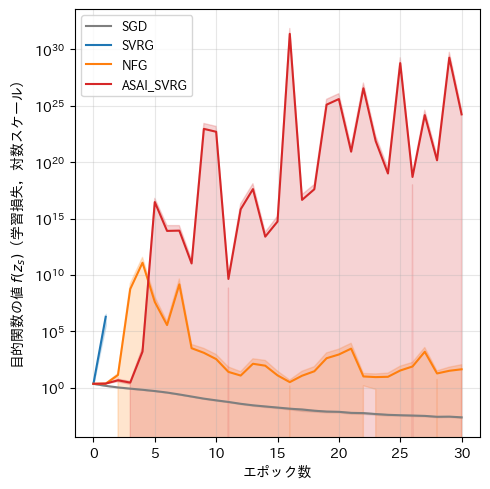

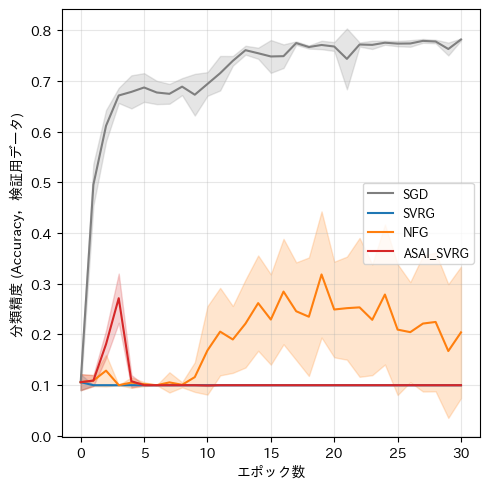

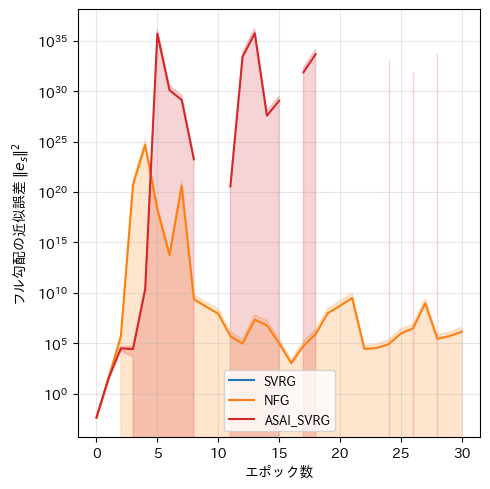

In [6]:
X_KEY_FOR_INDIVIDUAL = "epoch"
X_LABEL_FOR_INDIVIDUAL = "エポック数"

for y_key, y_label in Y_AXES:
    fig, ax = plt.subplots(figsize=(5, 5))

    for method in METHODS:
        if method in SKIP_METHOD_FOR_YKEY.get(y_key, set()):
            continue

        hp_name = resolve_hyperparams(all_results, EXPERIMENT, method, HYPERPARAMS)
        key = (EXPERIMENT, method, hp_name)
        if key not in all_results:
            continue

        seed_logs = all_results[key]["seed_logs"]
        x, mean, std = aggregate_seeds(
            seed_logs, X_KEY_FOR_INDIVIDUAL, y_key, x_scale=X_SCALE_BY_KEY[X_KEY_FOR_INDIVIDUAL]
        )

        color = METHOD_COLORS.get(method)
        ax.plot(x, mean, label=method, color=color, linewidth=1.5)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)

    if y_key in LOG_SCALE_YKEYS:
        ax.set_yscale("log")

    ax.set_xlabel(X_LABEL_FOR_INDIVIDUAL)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(save_dir / f"{y_key}_vs_{X_KEY_FOR_INDIVIDUAL}.png", dpi=150)
    plt.show()
